In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 📊 Étape 3 : Visualisation — l'histoire du football international

Cette étape est consacrée à la visualisation. On explore l'**histoire du football international** à travers six graphiques, à l'aide de notre module `src/utils_viz.py`.

**Donnée d'entrée :** `data/raw/results.csv` — l'historique **complet** des matchs (1872 → 2026). Ces visualisations décrivent l'histoire du football : elles utilisent toutes les données disponibles, et non la seule période d'entraînement du modèle (1992+).

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src import data_clean as dc
from src import utils_viz as uv

# Activation du style premium personnalisé (light ou dark)
uv.set_custom_style(theme='light')
%matplotlib inline
print("Librairies de visualisation prêtes !")

Librairies de visualisation prêtes !


### 2. Chargement et préparation

On charge l'historique complet des matchs, on écarte les rencontres non encore jouées, puis on enrichit le tableau avec `dc.feature_engineering` (`year`, `decade`, `total_goals`…). On prépare aussi la liste des **tournois majeurs**.

In [3]:
# Historique complet des matchs internationaux.
df = pd.read_csv('../data/raw/results.csv')
df = df[df['home_score'].notna()].copy()   # on écarte les matchs non encore joués
df_feat = dc.feature_engineering(df, 'date')

# Grands tournois internationaux : Coupe du Monde + championnats continentaux.
MAJOR_TOURNAMENTS = [
    'FIFA World Cup', 'UEFA Euro', 'Copa América', 'African Cup of Nations',
    'AFC Asian Cup', 'Gold Cup', 'CONCACAF Championship',
    'Oceania Nations Cup', 'Confederations Cup',
]

print(f"Matchs joués : {len(df_feat)}  ({df_feat['year'].min()} → {df_feat['year'].max()})")
df_feat.head()

Matchs joués : 49215  (1872 → 2026)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,decade,goal_difference,total_goals,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872,11,1870,0.0,0.0,draw
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873,3,1870,2.0,6.0,home_win
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874,3,1870,1.0,3.0,home_win
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875,3,1870,0.0,4.0,draw
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876,3,1870,3.0,3.0,home_win


### 3. Nombre de matchs par année

L'activité footballistique année par année. Les deux guerres mondiales et la pandémie de Covid-19 ressortent comme des **creux nets** dans le nombre de matchs.

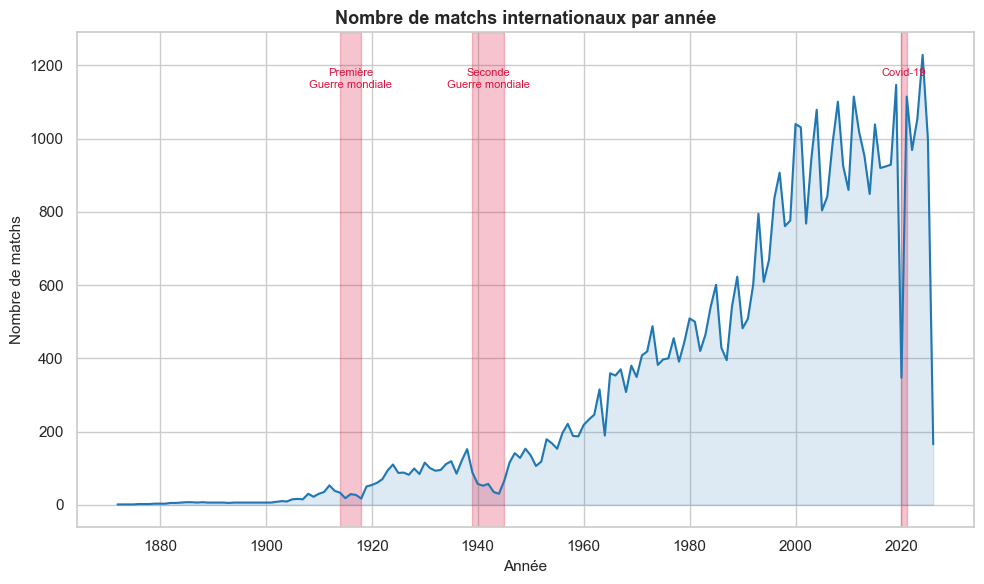

In [4]:
fig2 = uv.plot_matches_per_year(df_feat)
plt.show()

### 4. Tournois avec le plus de matchs

Les compétitions qui ont accueilli le plus grand nombre de rencontres dans l'histoire (matchs amicaux exclus : ce ne sont pas un tournoi).

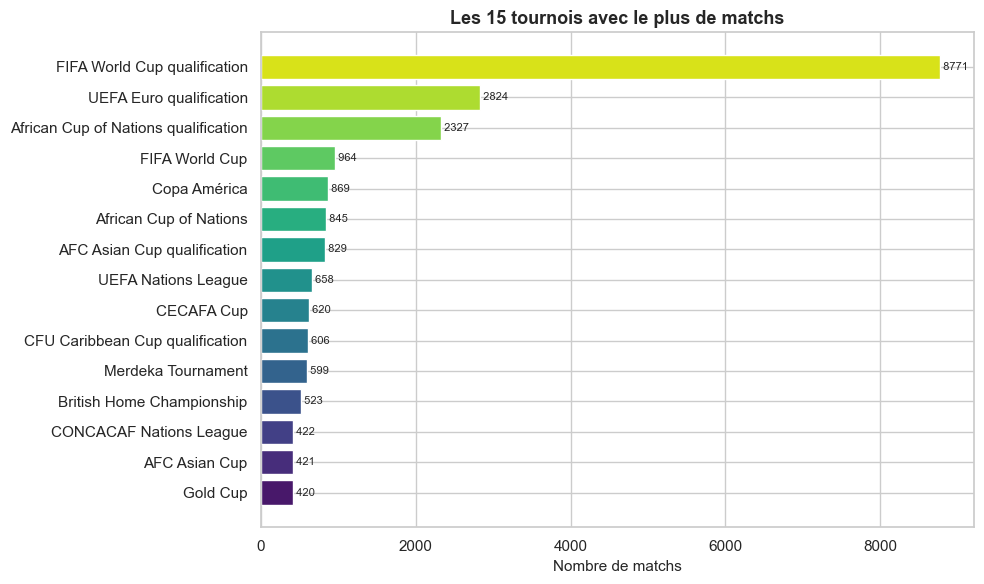

In [5]:
fig3 = uv.plot_top_tournaments(df_feat, n=15)
plt.show()

### 5. Équipes les plus présentes en tournois majeurs

Parmi les grands tournois (Coupe du Monde et championnats continentaux), quelles sélections ont disputé le plus de matchs ?

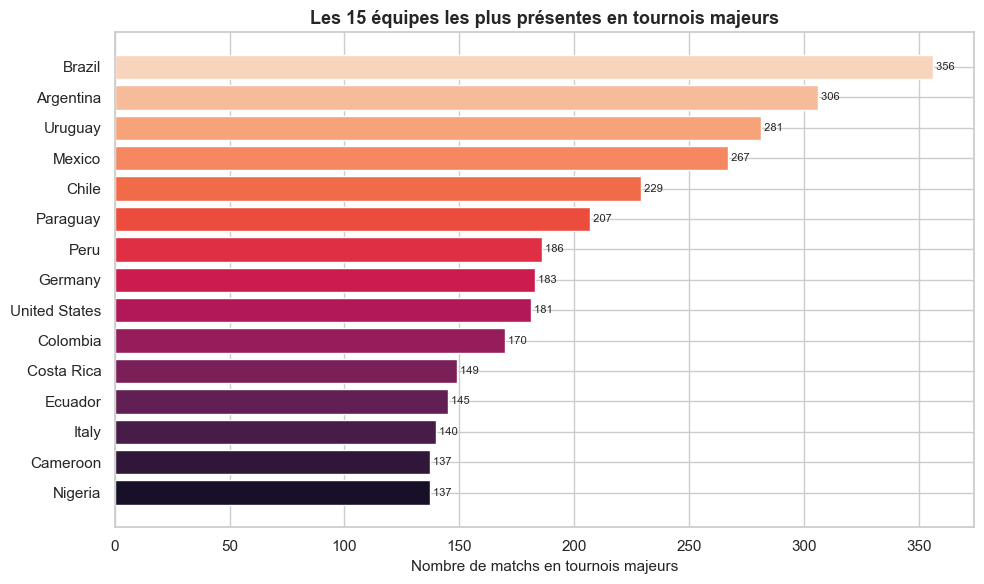

In [6]:
fig4 = uv.plot_teams_most_major(df_feat, MAJOR_TOURNAMENTS, n=15)
plt.show()

### 6. Nombre moyen de buts par match et par décennie

Le football est-il devenu plus ou moins offensif au fil des décennies ?

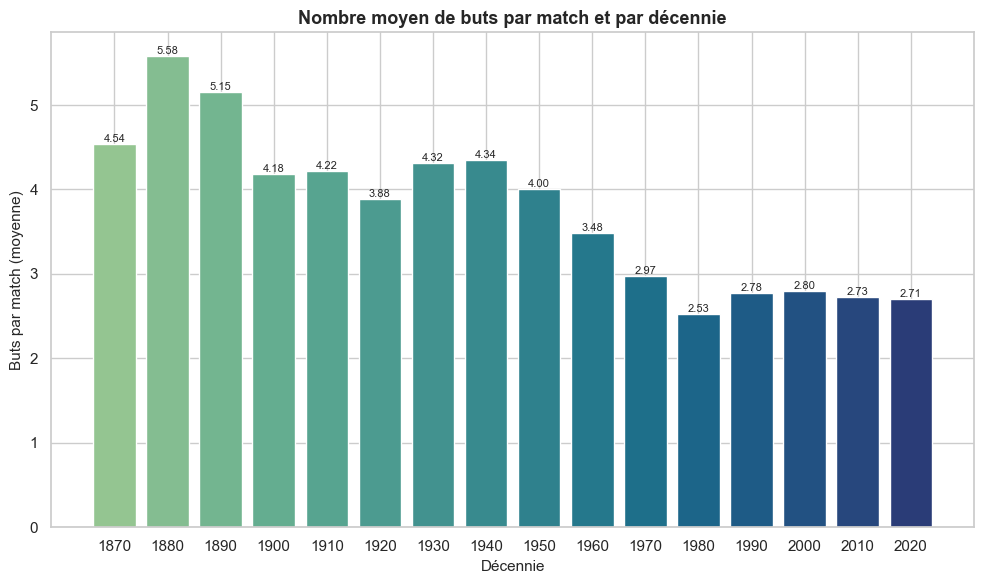

In [7]:
fig5 = uv.plot_avg_goals_per_decade(df_feat)
plt.show()

### 7. Meilleurs ratios de victoires en tournois majeurs

Les sélections les plus performantes dans les grands tournois — ratio victoires / matchs joués —, parmi celles ayant disputé au moins 30 matchs majeurs (seuil qui écarte les ratios non significatifs).

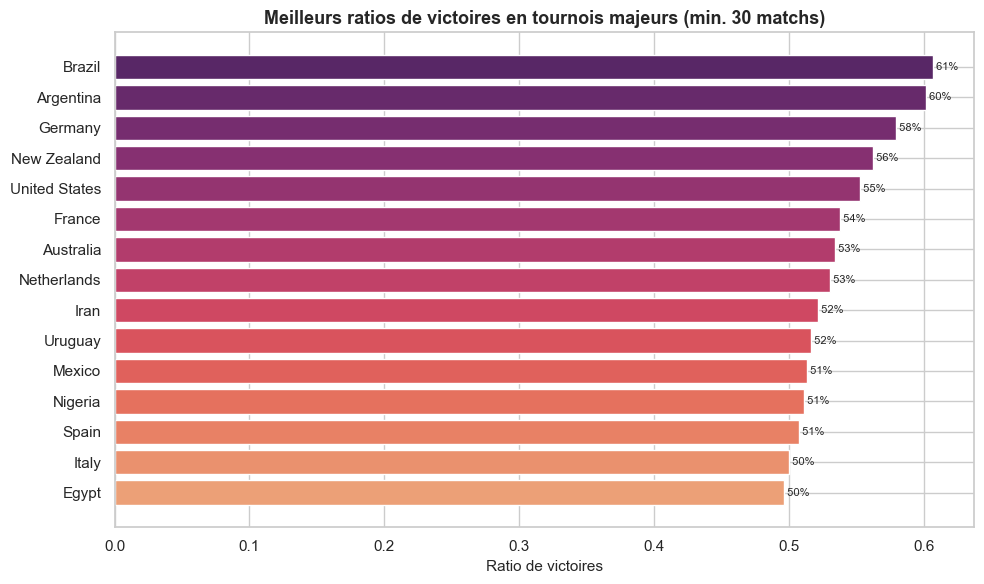

In [8]:
fig6 = uv.plot_best_win_ratios(df_feat, MAJOR_TOURNAMENTS, n=15, min_matches=30)
plt.show()

### 8. Évolution du pourcentage de matchs joués par jour de la semaine

Sept *small multiples*, un par jour de la semaine, montrent la part de matchs disputés ce jour-là année après année, jusqu'à 2018 exclu (on écarte les années marquées par la pandémie de Covid-19 et celles encore en cours). On distingue ainsi nettement les jours « traditionnels » du football international.

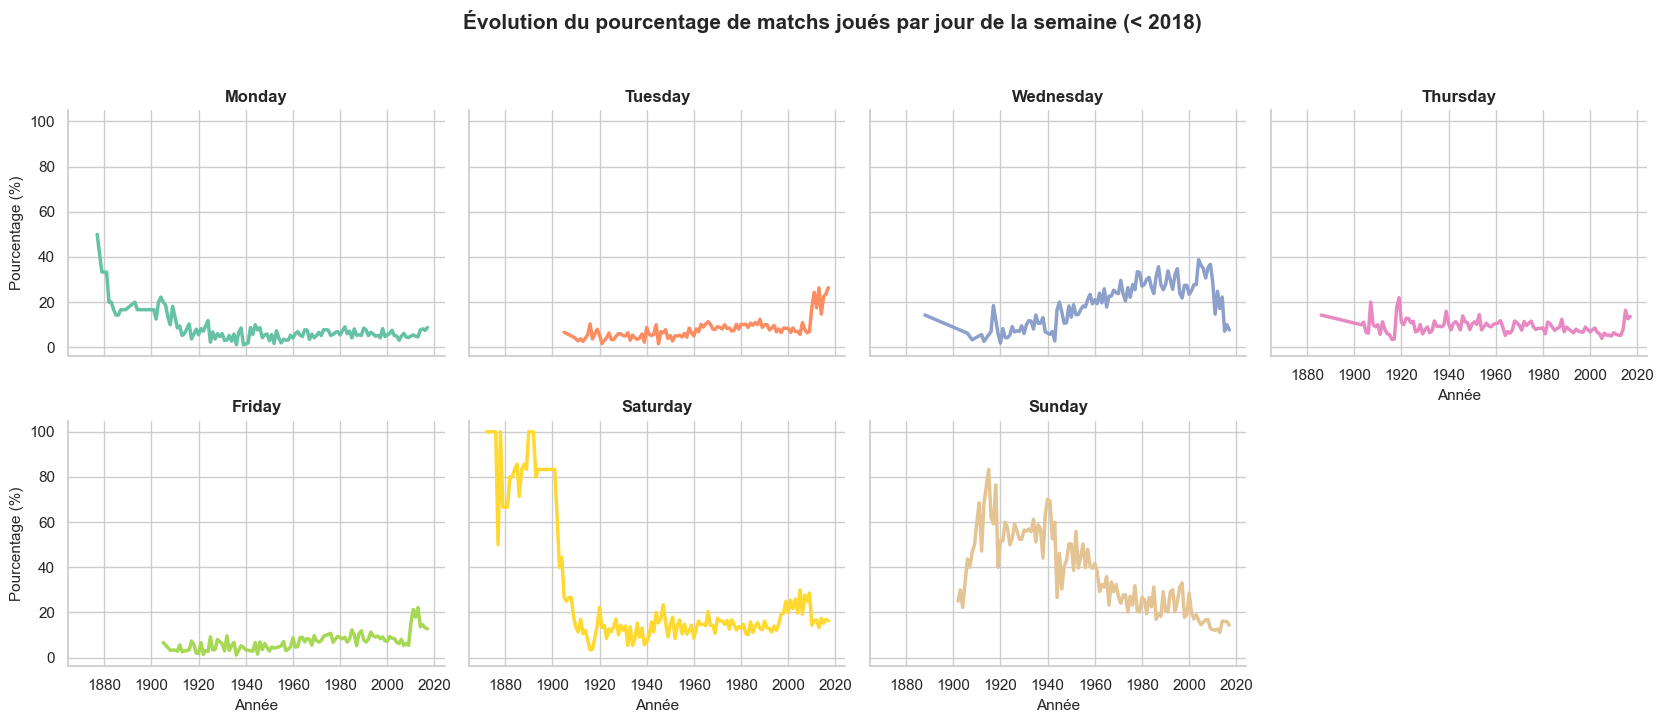

In [9]:
fig7 = uv.plot_weekday_evolution(df_feat, year_max=2018)
plt.show()